Shape: (440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicas

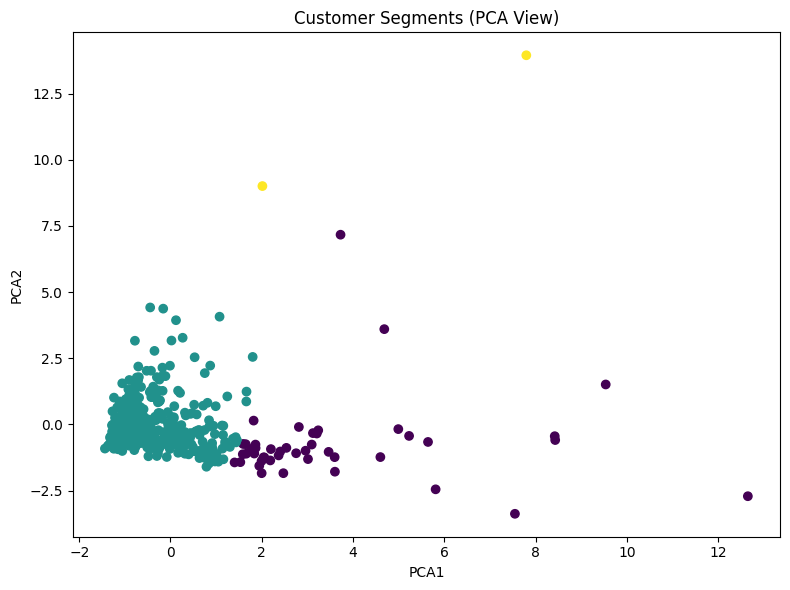


Clustered dataset saved as wholesale_customers_clustered.csv


In [2]:
# pip install ucimlrepo pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from ucimlrepo import fetch_ucirepo

# -----------------------------
# 1. Load real dataset from UCI
# -----------------------------
wholesale_customers = fetch_ucirepo(id=292)
df = wholesale_customers.data.original.copy()

print("Shape:", df.shape)
print(df.head())
print(df.info())

# -----------------------------
# 2. Select spending columns
# -----------------------------
feature_cols = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]

X = df[feature_cols].copy()

# -----------------------------
# 3. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4. Find a good k using silhouette score
# -----------------------------
scores = []
k_values = range(2, 8)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette_score={score:.4f}")

best_k = k_values[scores.index(max(scores))]
print(f"\nBest k based on silhouette score: {best_k}")

# -----------------------------
# 5. Train final model
# -----------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# -----------------------------
# 6. Cluster summary
# -----------------------------
cluster_summary = df.groupby("Cluster")[feature_cols].mean().round(2)
print("\nCluster Summary:")
print(cluster_summary)

# -----------------------------
# 7. PCA for 2D visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Cluster": df["Cluster"]
})

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["PCA1"], plot_df["PCA2"], c=plot_df["Cluster"])
plt.title("Customer Segments (PCA View)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.savefig("Customer segmentation.png", dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 8. Optional: save results
# -----------------------------
df.to_csv("wholesale_customers_clustered.csv", index=False)
print("\nClustered dataset saved as wholesale_customers_clustered.csv")